In [1]:
import json
import pathlib
import os
import sqlite3
import sys
import urllib

import dns.rdatatype
import duckdb
import IPython.display
import pandas
import polars
import swifter
import tqdm.notebook

JSON2CBOR_EVAL_DIR = pathlib.Path.cwd()
os.environ["JSON2CBOR_EVAL_DIR"] = str(JSON2CBOR_EVAL_DIR)

if str((JSON2CBOR_EVAL_DIR / "..").absolute()) not in sys.path:
    sys.path.append(str((JSON2CBOR_EVAL_DIR / "..").absolute()))

from utils import list_code

# Measure Request/Response Times

## Create Initial Databases and Indices

### Collect URLs from HTTP Archive

We used the following SQL instructions to download from the legacy BigQuery database of the HTTP archive on September 30, 2024 (no longer available):

In [2]:
list_code(JSON2CBOR_EVAL_DIR / "input_datasets" / "bq-results-20240930-154613-1727711199326.sql")

SELECT
  resp_content_type, url
FROM `httparchive.summary_requests.2024_09_01_desktop`
WHERE 
  LOWER(resp_content_type) LIKE "%json%" OR
  LOWER(resp_content_type) LIKE "%text/html%" OR
  LOWER(resp_content_type) LIKE "%text/css%"
LIMIT 1000000;

This resulted in a CSV file we provide in `./03_json2cbor_eval/input_datasets` in `03_json2cbor_eval.tar.zst` on OPARA. Below we reformat it with tabs as separation characters to make parsing easier for the following setup steps.

In [3]:
lf = polars.scan_csv(
    JSON2CBOR_EVAL_DIR / "input_datasets" / "bq-results-20240930-154613-1727711199326.csv"
)
IPython.display.display(lf.collect())
# minor correction of content type with control characters to avoid parsing error.
lf = lf.with_columns(
    resp_content_type=polars.when(
        (polars.col("url") == "https://advisorservices.schwab.com/api/getlocation")
    ).then(
        polars.lit("text/html")
    ).otherwise(
        polars.col("resp_content_type")
    )
)
lf.sink_csv(
    JSON2CBOR_EVAL_DIR / "input_datasets" / "bq-results-20240930-154613-1727711199326_tabbed.csv",
    separator="\t",
)

resp_content_type,url
str,str
"""application/expanded+json;char…","""https://chanellos33.foodtecsol…"
"""application/ion+json;okta-vers…","""https://cbsi.okta.com/idp/idx/…"
"""application/json""","""https://prodlenka.online/i18n/…"
"""application/json""","""https://www.munakata-live.com/…"
"""application/json""","""https://sluban.nl/style/favico…"
…,…
"""text/css; charset=utf-8""","""https://fonts.googleapis.com/c…"
"""text/css; charset=utf-8""","""https://fonts.googleapis.com/c…"
"""text/css; charset=utf-8""","""https://fonts.googleapis.com/c…"


### Download HTTP Content to SQLite Database

For faster access to the unconverted and converted objects, we create a SQLite database from the CSV file above that contains both JSON and CBOR objects. For this we use the `web_to_cbor.py` script. It also creates an experimental HTML and CSS format in CBOR, which we briefly discuss in our Discussion section but did not further evaluate in the paper.

In [4]:
list_code(JSON2CBOR_EVAL_DIR / "req_resp_harch_init.sql")

PRAGMA journal_mode = WAL;
PRAGMA foreign_keys = ON;
CREATE TABLE IF NOT EXISTS objects (
    id INTEGER PRIMARY KEY,
    url TEXT NOT NULL,
    type TEXT NOT NULL,
    orig_len INTEGER NOT NULL,
    object BLOB NOT NULL
);
CREATE TABLE IF NOT EXISTS errors (
    id INTEGER PRIMARY KEY,
    url TEXT NOT NULL,
    lib TEXT NOT NULL,
    error TEXT NOT NULL
);
CREATE TABLE IF NOT EXISTS keys (
    id INTEGER PRIMARY KEY,
    obj_id INTEGER NOT NULL,
    key TEXT NOT NULL,
    count INTEGER NOT NULL,
    FOREIGN KEY (obj_id)
       REFERENCES objects (id)
);
CREATE TABLE IF NOT EXISTS special_values (
    id INTEGER PRIMARY KEY,
    key_id INTEGER NOT NULL,
    value TEXT NOT NULL,
    count INTEGER NOT NULL,
    FOREIGN KEY (key_id)
       REFERENCES keys (id)
);
CREATE INDEX IF NOT EXISTS url_idx ON objects(url);
CREATE INDEX IF NOT EXISTS error_idx ON errors(url);

In [5]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/output_datasets/http-archive.db"

rm -f "${DATABASE}"*
sqlite3 -batch "${DATABASE}" < "${JSON2CBOR_EVAL_DIR}"/req_resp_harch_init.sql

wal


In [6]:
list_code(JSON2CBOR_EVAL_DIR / "web_to_cbor.py")

#! /usr/bin/env python3
#
# Copyright (C) 2024 Martine S. Lenders <martine.lenders@tu-dresden.de>
#
# Distributed under terms of the MIT license.


import argparse
import collections
import json
import re
import sqlite3
import sys
import traceback
import warnings

import bs4
import json5
import requests
import requests.exceptions
import tinycss2
import urllib3.exceptions


KEYS = {}
SPECIAL_VALUES = {}


def update_stats(key, value=None):
    if key in KEYS:
        KEYS[key] += 1
    else:
        KEYS[key] = 1
    if value is not None:
        if key in SPECIAL_VALUES:
            if value in SPECIAL_VALUES[key]:
                SPECIAL_VALUES[key][value] += 1
            else:
                SPECIAL_VALUES[key][value] = 1
        else:
            try:
                SPECIAL_VALUES[key] = {value: 1}
            except TypeError:
                print(key, value)


def add_navigable_string(name, content):
    if re.match(r"^\s*$", content) and name not in [
        "!-- COMMENT",
        "!CDATA",
        "!DOCTYPE",
    ]:
        # content only white spaces so effectively empty
        return {}
    if name != "str":
        update_stats("NAME", name)
        update_stats("CONTENT")
    return {"NAME": name, "CONTENT": [content]}


def xml_child_to_dict(elem):
    tag = {}
    if isinstance(elem, bs4.Declaration):
        tag = add_navigable_string("?xml", elem.string)
    elif isinstance(elem, bs4.ProcessingInstruction):
        tag = add_navigable_string("?PI", elem.string)
    elif isinstance(elem, bs4.Doctype):
        tag = add_navigable_string("!DOCTYPE", elem.string)
    elif isinstance(elem, bs4.CData):
        tag = add_navigable_string("!CDATA", elem.string)
    elif isinstance(elem, bs4.Stylesheet):
        tag = add_navigable_string("<STYLESHEET", elem.string)
    elif isinstance(elem, bs4.Script):
        tag = add_navigable_string("<SCRIPT", elem.string)
    elif isinstance(elem, bs4.Comment):
        tag = add_navigable_string("!-- COMMENT", elem.string)
    elif isinstance(elem, bs4.TemplateString):
        tag = add_navigable_string("<TEMPLATE", elem.string)
    elif isinstance(elem, bs4.NavigableString):
        if type(elem) != bs4.NavigableString:
            raise ValueError(f"Unknown element, {type(elem)}, {elem}")
        tag = add_navigable_string("str", elem.string)
    elif isinstance(elem, bs4.Tag):
        children = xml_children_to_dicts(elem)

        tag = {
            "NAME": elem.name.lower(),
        }
        update_stats("NAME", elem.name.lower())
        if children:
            update_stats("CONTENT")
            tag["CONTENT"] = children
        for key in elem.attrs:
            lower_key = key.lower()
            if lower_key in ["class", "id", "style", "accesskey"]:
                continue
            if lower_key in ["rel", "accept-charset"]:
                for value in elem.attrs[key]:
                    update_stats(lower_key, value)
            else:
                update_stats(lower_key, elem.attrs[key])
            tag[lower_key] = elem.attrs[key]
    else:
        raise ValueError(f"Unknown element, {type(elem)}, {elem}")
    return tag


def xml_children_to_dicts(parent):
    res = []
    for elem in parent.childGenerator():
        tag = xml_child_to_dict(elem)
        if tag:
            res.append(tag)
        elif type(elem) not in [bs4.Script, bs4.Stylesheet, bs4.TemplateString]:
            assert (
                type(elem) == bs4.NavigableString
            ), f"OK to skip? {type(elem)}, {repr(elem)}, {elem.parent}"
    return res


class CSSTokenList:
    def __init__(self, init=None):
        if init is None:
            self._list = []
        else:
            self._list = init

    def __repr__(self):
        return f"<CSSTokenList {self._list}>"

    def append(self, element):
        self._list.append(element)

    @property
    def list(self):
        return self._list


def append_css_token(lst, token):
    if isinstance(lst, list):
        # append

To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${JSON2CBOR_EVAL_DIR}'/../.env/bin/python` before the `${JSON2CBOR_EVAL_DIR}/web_to_cbor.py`):

In [7]:
%%bash

PROCS=$(grep -c '^processor' /proc/cpuinfo)
REQUESTS="${JSON2CBOR_EVAL_DIR}/input_datasets/bq-results-20240930-154613-1727711199326_tabbed.csv"
DATABASE="${JSON2CBOR_EVAL_DIR}/output_datasets/http-archive.db"

if [ $PROCS -gt 64 ]; then
    # leave some resources to collegues ;-)
    PROCS=$(( (PROCS * 1) / 4))
fi

tmux new -s "web_to_cbor" -d " \
    awk -F'\t' 'NR > 1 {print \$2}' '${REQUESTS}' | \
        parallel -j${PROCS} -I'{}' \
            ${JSON2CBOR_EVAL_DIR}/web_to_cbor.py '${DATABASE}' '{}' \
                2> ${JSON2CBOR_EVAL_DIR}/output_datasets/web_to_cbor.log"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "web_to_cbor"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "web_to_cbor" C-c
```

In [8]:
with sqlite3.connect(JSON2CBOR_EVAL_DIR / "output_datasets" / "http-archive.db") as con:
    df = polars.read_database(
        """
        SELECT type, count(id) as count FROM objects GROUP BY type;
        """,
        con
    )
IPython.display.display(df)
df["count"].sum()

type,count
str,i64
"""css""",171669
"""html""",112191
"""json""",47771


331631

### Create Format Index Files

In [9]:
with sqlite3.connect(JSON2CBOR_EVAL_DIR / "output_datasets" / "http-archive.db") as con:
    cursor = con.execute(
        """
        SELECT key, SUM(count) AS total_count 
        FROM keys
        JOIN objects ON keys.obj_id = objects.id
        WHERE type == "html"
        GROUP BY key
        ORDER BY total_count DESC;
        """
    )
    idx = 0
    res = {}
    for key, _ in tqdm.notebook.tqdm(cursor.fetchall()):
        if (23 < idx < 0xff and len(key) == 1) or (0xff < idx < 0xffff and len(key) < 3):
            # idx would increase size in CBOR compared to string
            continue
        res[key] = idx
        idx += 1
    with open(JSON2CBOR_EVAL_DIR / "output_datasets" / "html-key-idx.json", "wt") as jf:
        json.dump(res, jf, separators=(",", ":"))
    cursor = con.execute(
        """
        SELECT value, SUM(special_values.count) AS total_count 
        FROM special_values
        JOIN keys ON special_values.key_id = keys.id
        JOIN objects ON keys.obj_id = objects.id
        WHERE type == "html" AND key == "NAME" AND value != "str"
        GROUP BY value
        ORDER BY total_count DESC;
        """
    )
    idx = 0
    res = {}
    for key, _ in tqdm.notebook.tqdm(cursor.fetchall()):
        if (23 < idx < 0xff and len(key) == 1) or (0xff < idx < 0xffff and len(key) < 3):
            # idx would increase size in CBOR compared to string
            continue
        res[key] = idx
        idx += 1
    with open(JSON2CBOR_EVAL_DIR / "output_datasets" / "html-name-idx.json", "wt") as jf:
        json.dump(res, jf, separators=(",", ":"))
    cursor = con.execute("""
        SELECT key, SUM(count) AS total_count 
        FROM keys
        JOIN objects ON keys.obj_id = objects.id
        WHERE type == "css"
        GROUP BY key
        ORDER BY total_count DESC;
    """)
    idx = 0
    res = {}
    for key, _ in tqdm.notebook.tqdm(cursor.fetchall()):
        if (23 < idx < 0xff and len(key) == 1) or (0xff < idx < 0xffff and len(key) < 3):
            # idx would increase size in CBOR compared to string
            continue
        res[key] = idx
        idx += 1
    with open(JSON2CBOR_EVAL_DIR / "output_datasets" / "css-ident-idx.json", "wt") as jf:
        json.dump(res, jf, separators=(",", ":"))

  0%|          | 0/20985 [00:00<?, ?it/s]

  0%|          | 0/2574 [00:00<?, ?it/s]

  0%|          | 0/158498 [00:00<?, ?it/s]

### Collect DNS Data

In [10]:
list_code(JSON2CBOR_EVAL_DIR / "collect_dns.sh")

#! /bin/bash
#
# collect_dns.sh
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR="$( cd -- "$( dirname -- "${BASH_SOURCE[0]}" )" &> /dev/null && pwd )"
REQUESTS=${REQUESTS:-${SCRIPT_DIR}/input_datasets/bq-results-20240930-154613-1727711199326_tabbed.csv}

PROCS=$(grep -c '^processor' /proc/cpuinfo)
if [ $PROCS -gt 64 ]; then
    # leave some resources to collegues ;-)
    PROCS=$(( (PROCS * 3) / 4))
fi

DATABASE="${SCRIPT_DIR}/output_datasets/dns-responses.db"
DOH_UPSTREAM=https://dns.google/dns-query

while getopts "d:D:" opt; do
    case "${opt}" in
        d)  DATABASE="${OPTARG}";;
        D)  DOH_UPSTREAM="${OPTARG}";;
    esac
done

collect_dns() {
    "${SCRIPT_DIR}"/collect_dns.py "${DOH_UPSTREAM}" "${DATABASE}" "$1"
}

export -f collect_dns
export SCRIPT_DIR
export DATABASE
export DOH_UPSTREAM

awk -F'\t' 'NR > 1 {print $2}' "${REQUESTS}" | parallel -j${PROCS} collect_dns

In [11]:
list_code(JSON2CBOR_EVAL_DIR / "collect_dns.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import sqlite3
import urllib.parse

import dns.message
import dns.query

from scapy.all import DNS as ScapyDNS


def fetch_record(upstream_doh, con, hostname, qtype):
    cur = con.execute(
        """
        SELECT resp FROM dns_responses WHERE name = ? AND type = ?
        """,
        (hostname, qtype)
    )
    res = cur.fetchone()
    if res is None:
        dns_query = dns.message.make_query(hostname, qtype)
        dns_resp = dns.query.https(dns_query, upstream_doh)
        scapy_resp = ScapyDNS(dns_resp.to_wire())
        if scapy_resp.an:
            for i in range(scapy_resp.ancount):
                if scapy_resp.an[i].rclass != 1:
                    continue
                if scapy_resp.an[i].type == 1:
                    scapy_resp.an[i].ttl = 0
                    scapy_resp.an[i].rdata = "127.0.0.1"
                elif scapy_resp.an[i].type == 28:
                    scapy_resp.an[i].ttl = 0
                    scapy_resp.an[i].rdata = "::1"
            scapy_resp.id = 0
            res = dns.message.from_wire(bytes(scapy_resp)).to_text()
        while True:
            try:
                con.execute(
                    "INSERT INTO dns_responses (name, type, resp) VALUES (?, ?, ?)",
                    (hostname, qtype, res),
                )
                con.commit()
                break
            except sqlite3.OperationalError as exc:
                if exc.sqlite_errorcode != 5:
                    raise
            except sqlite3.IntegrityError:
                break
        return res
    else:
        return res[0]


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("upstream_doh")
    parser.add_argument("database")
    parser.add_argument("url")
    args = parser.parse_args()

    with sqlite3.connect(args.database) as con:
        while True:
            try:
                con.execute("pragma journal_mode = WAL;")
                con.execute("pragma foreign_keys = ON;")
                con.execute(
                    """
                    CREATE TABLE IF NOT EXISTS dns_responses (
                        id INTEGER PRIMARY KEY,
                        name TEXT NOT NULL,
                        type INTEGER NOT NULL,
                        resp TEXT DEFAULT NULL,
                        UNIQUE(name, type)
                    );
                    """
                )
                con.execute(
                    "CREATE INDEX IF NOT EXISTS name_idx ON dns_responses(name, type);"
                )
                con.commit()
                break
            except sqlite3.OperationalError as exc:
                if exc.sqlite_errorcode != 5:
                    raise
        parts = urllib.parse.urlparse(args.url)
        fetch_record(args.upstream_doh, con, parts.hostname, 1)
        fetch_record(args.upstream_doh, con, parts.hostname, 28)




if __name__ == "__main__":
    main()

To start a detached TMUX session running this script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${JSON2CBOR_EVAL_DIR}'/../.env/bin/activate;` before the `${JSON2CBOR_EVAL_DIR}/collect_dns.sh`):

In [12]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/output_datasets/dns-responses.db"
DOH_UPSTREAM="https://dns.google/dns-query"

tmux new -s "collect_dns" -d "\
    '${JSON2CBOR_EVAL_DIR}'/collect_dns.sh -D '${DOH_UPSTREAM}' -d '${DATABASE}' \
                2> ${JSON2CBOR_EVAL_DIR}/output_datasets/collect_dns.log"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "collect_dns"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "collect_dns" C-c
```

In [13]:
database = JSON2CBOR_EVAL_DIR / "output_datasets" / "dns-responses.db"

with sqlite3.connect(database) as con:
    df = polars.read_database(
        """
        SELECT type, count(0) as count
        FROM dns_responses
        WHERE resp
        NOT NULL GROUP BY type;
        """,
        con,
    )

df = df.with_columns(
    polars.col("type").map_elements(
        lambda x: dns.rdatatype.RdataType.to_text(x),
        return_dtype=str,
    )
)

IPython.display.display(df)
df["count"].sum()

type,count
str,i64
"""A""",465865
"""AAAA""",207804


673669

## Measurements

For this section you need a TLS certificate.

```console
$ cd 03_json2cbor_eval
$ openssl req -newkey rsa:2048 -nodes -keyout domain.key -out domain.csr
```

Provide `localhost` as Common Name, everything else is arbitrary. We recommend leaving the challenge password unset for ease of use (but not for production ;-)).

```console
$ openssl x509 -signkey domain.key -in domain.csr -req -days 365 -out domain.crt
```

In [14]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}

\usepackage[T1]{fontenc}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}

\usepackage{tikz}

\usetikzlibrary{
  calc,
  colorbrewer,
  decorations.pathreplacing,
  fit,
  positioning,
  shapes.geometric,
}
\pgfdeclarelayer{bg}
\pgfdeclarelayer{fg}
\pgfsetlayers{bg,main,fg}
\graphicspath{{figs/}}
"""

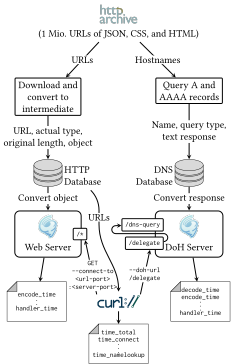

In [15]:
%%tikz -p "$preamble" -S "figs/req-resp-setup")
\input{figs/req-resp-setup.tex}

### Web Server

In [16]:
list_code(JSON2CBOR_EVAL_DIR / "web_server.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.

import argparse
import asyncio
import base64
import collections
import json
import pathlib
import re
import sqlite3
import sys
import time
import urllib.parse
import timeit
import traceback

import cbor2
import dns.message
import dns.query
import tornado
import ssl


SCRIPT_PATH = pathlib.Path(__file__).parent


def encode_html(obj):
    res = ""
    for elem in obj:
        assert "NAME" in elem, f'"NAME" not in {elem} of {obj}'
        if elem["NAME"] == "?xml":
            res += f"<?xml {elem['CONTENT'][0]}>"
        elif elem["NAME"] == "?PI":
            res += f"<?{elem['CONTENT'][0]}>"
        elif elem["NAME"] == "!DOCTYPE":
            res += f"<!DOCTYPE {elem['CONTENT'][0]}>"
        elif elem["NAME"] == "!CDATA":
            res += f"<![CDATA[{elem['CONTENT'][0]}]]>"
        elif elem["NAME"] == "<STYLESHEET":
            res += f"{elem['CONTENT'][0]}"
        elif elem["NAME"] == "<SCRIPT":
            res += f"{elem['CONTENT'][0]}"
        elif elem["NAME"] == "!-- COMMENT":
            res += f"<!--{elem['CONTENT'][0]}-->"
        elif elem["NAME"] == "TEMPLATE":
            res += f"{elem['CONTENT'][0]}"
        elif elem["NAME"] == "str":
            res += f"{elem['CONTENT'][0]}"
        else:
            res += f"<{elem['NAME']}"
            for key in elem:
                if key in ["NAME", "CONTENT"]:
                    continue
                res += f' {key}="{elem[key]}"'
            if "CONTENT" in elem:
                res += ">"
                res += encode_html(elem["CONTENT"])
                res += f"</{elem['NAME']}>"
            else:
                res += "/>"
    return res


def encode_css_rule(obj):
    res = "{"
    if obj is not None:
        for key, value in obj.items():
            if isinstance(value, list):
                for val in value:
                    res += f"{key}:{val};"
            else:
                res += f"{key}:{value};"
    res += "}"
    return res


def encode_css(obj):
    res = ""
    for key, value in obj.items():
        if key.startswith("@"):
            # is object a dictionary of rules?
            if obj[key] and isinstance(obj[key][[k for k in obj[key]][0]], dict):
                # recurse deeper
                if isinstance(value, list):
                    for val in value:
                        res += f"{key}" "{" f"{encode_css(val)}" "}"
                else:
                    res += f"{key}" "{" f"{encode_css(value)}" "}"
            else:
                # interpret as directly as rule
                if isinstance(value, list):
                    for val in value:
                        res += f"{key}" "{" f"{encode_css_rule(val)}" "}"
                else:
                    res += f"{key}{encode_css_rule(value)}"
        else:
            if isinstance(value, list):
                for val in value:
                    res += f"{key}" "{" f"{encode_css_rule(val)}" "}"
            else:
                res += f"{key}{encode_css_rule(value)}"
    return res


def encode_cbor_html_obj(obj, html_key_idx, html_name_idx):
    res = []
    for elem in obj:
        assert isinstance(elem, (str, dict))
        if isinstance(elem, str):
            res.append(elem)
        elif elem.get("NAME") == "str":
            res.append(elem["CONTENT"][0])
        else:
            item = {}
            for key, val in elem.items():
                if key == "NAME":
                    item[html_key_idx.get(key, key)] = html_name_idx.get(val, val)
                elif key == "CONTENT":
                    item[html_key_idx.get(key, key)] = encode_cbor_html_obj(
                        val,
                        html_key_idx,
                        html_name_idx,
                    )
                else:
                    item[html_key_idx.get(key, key)] = val
            res.append(item)
    return res


def encode_cbor_h

### DNS Server

In [17]:
list_code(JSON2CBOR_EVAL_DIR / "dns_server.py")

#! /usr/bin/env python3
# vim:fenc=utf-8
#
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.


import argparse
import asyncio
import io
import pathlib
import sqlite3
import socket
import sys
import time
import timeit

import dns.asyncbackend
import dns.message
import dns.inet
import httpx
import ssl
import tornado

from typing import Optional, Union

from dns.query import (
    have_doh,
)
from scapy.all import DNS as ScapyDNS


SCRIPT_PATH = pathlib.Path(__file__).parent
CBOR4DNS_PATH = (SCRIPT_PATH / ".." / "04_cbor4dns_eval" / "cbor4dns").resolve()

if CBOR4DNS_PATH not in sys.path:
    sys.path.append(str(CBOR4DNS_PATH))
import cbor4dns.encode
import cbor4dns.decode


def decode_cbor_query(cbor):
    with io.BytesIO(cbor) as cbor_file:
        decoder = cbor4dns.decode.Decoder(cbor_file)
        return decoder.decode(cbor4dns.decode.MsgType.QUERY)


def decode_cbor_response(cbor, query_msg=None, packed=False):
    with io.BytesIO(cbor) as cbor_file:
        decoder = cbor4dns.decode.Decoder(cbor_file)
        return decoder.decode(cbor4dns.decode.MsgType.RESPONSE, query_msg, packed)


def encode_cbor(msg, query_msg=None, packed=False):
    with io.BytesIO() as cbor_file:
        encoder = cbor4dns.encode.Encoder(cbor_file, packed)
        encoder.encode(msg, query_msg)
        return cbor_file.getvalue()


class DoHLookupHandler(tornado.web.RequestHandler):
    def initialize(self, db_con):
        self._db_con = db_con

    async def post(self):
        resp_start = time.time()
        msgs = {}
        if self.request.headers.get("Content-Type") == "application/dns+cbor":
            cbor = True
            def decode_cbor():
                msgs["query"] = decode_cbor_query(self.request.body)
            decode_time = timeit.timeit(decode_cbor, number=1)
        else:
            cbor = False
            def decode_dns():
                msgs["query"] = dns.message.from_wire(self.request.body)
            decode_time = timeit.timeit(decode_dns, number=1)
        query = msgs["query"]
        question = query.question[0]
        name = question.name.to_text(omit_final_dot=True)
        qtype = question.rdtype
        cur = self._db_con.execute(
            """
            SELECT resp
            FROM dns_responses
            WHERE name = ? AND type = ?;
            """,
            (name, qtype),
        )
        res = cur.fetchone()
        if res and res[0]:
            resp = dns.message.from_text(res[0])
        else:
            resp = dns.message.make_response(query)

        if self.request.headers.get("Accept") == "application/dns+cbor":
            def encode_cbor_response():
                msgs["resp"] = encode_cbor(resp, self.request.body)
            self.set_header("Content-Type", "application/dns+cbor")
            encode_time = timeit.timeit(encode_cbor_response, number=1)
        elif self.request.headers.get("Accept") == "application/dns+cbor;packed=1":
            def encode_cbor_packed_response():
                msgs["resp"] = encode_cbor(resp, self.request.body, packed=True)
            self.set_header("Content-Type", "application/dns+cbor;packed=1")
            encode_time = timeit.timeit(encode_cbor_packed_response, number=1)
        else:
            def encode_dns_response():
                msgs["resp"] = resp.to_wire()
            self.set_header("Content-Type", "application/dns-message")
            encode_time = timeit.timeit(encode_dns_response, number=1)
        write_start = time.time()
        self.write(msgs["resp"])
        print(
            "doh-endpoint",
            name,
            qtype,
            resp_start,
            "",
            decode_time,
            encode_time,
            write_start,
            time.time() - resp_start,
            sep="\t",
        )


async def doh_query(
    q: dns.message.Message,
    where: str,
    timeout: Optional[float] = None,
    port: int = 443,
    source: Optional[str] = None,
    source_port: int =

### Web Client

In [18]:
list_code(JSON2CBOR_EVAL_DIR / "web_client.sh")

#! /bin/bash
#
# web_client.sh
# Copyright (C) 2024 TU Dresden
#
# Distributed under terms of the MIT license.
#

SCRIPT_DIR="$( cd -- "$( dirname -- "${BASH_SOURCE[0]}" )" &> /dev/null && pwd )"

PROCS=$(grep -c '^processor' /proc/cpuinfo)
if [ $PROCS -gt 8 ]; then
    # leave some resources to collegues ;-)
    PROCS=8   #$(( (PROCS * 3) / 4))
fi
COUNT=1000
DATABASE="${SCRIPT_DIR}/output_datasets/http-archive.db"
DOH_PORT=8053
HTTP_PORT=8888
HTTPS_PORT=8433
COMPRESSED_FLAG=

while getopts "d:gn:p:s:D:" opt; do
    case "${opt}" in
        d)  DATABASE="${OPTARG}";;
        D)  DOH_PORT="${OPTARG}";;
        g)  COMPRESSED_FLAG="--compressed";;
        n)  COUNT="${OPTARG}";;
        p)  HTTP_PORT="${OPTARG}";;
        s)  HTTPS_PORT="${OPTARG}";;
        *)  ;;
    esac
done

if [ "$COUNT" -le 1 ]; then
    COUNT=1
fi

HEADER="%{url_effective}\t%{content_type}\t%{http_version}\t%{time_namelookup}\t"
HEADER="${HEADER}%{time_connect}\t%{time_appconnect}\t%{time_pretransfer}\t%{time_redirect}\t"
HEADER="${HEADER}%{time_starttransfer}\t%{time_total}\n"

echo -ne "after_time\tstart_time\tdoh_a_completed\tdoh_aaaa_completed\treq_time\tbefore_time\tid\turl\ttype\t${HEADER}" | sed -e 's/%{//g' -e 's/}//g'

request() {
    ID=$(echo "$1" | cut -f1 -d\|)
    URL=$(echo "$1" | cut -f2 -d\|)
    TYPE=$(echo "$1" | cut -f3 -d\|)

    if [[ ${URL} == http:* ]]; then
        PORT="${HTTP_PORT}"
        SPORT=80
    elif [[ ${URL} == https:* ]]; then
        PORT="${HTTPS_PORT}"
        SPORT=443
    fi
    if [[ ${URL} == *"?"* ]]; then
        if [[ ${URL} == *"?" ]]; then
            SEP=""
        else
            SEP="&"
        fi
    else
        SEP="?"
    fi
    HOST_PART=$(echo "${URL}" | sed -E 's#^https?://([^/]+)/.*$#\1#')
    if ! [[ ${HOST_PART} == *":"* ]]; then
        HOST_PART="${HOST_PART}:${SPORT}"
    fi
    HOST=$(echo "${HOST_PART}" | cut -d: -f1)
    URL=$(echo "${URL}" | sed -e 's/\[/\\[/g' -e 's/]/\\]/g' -e 's/{/\\{/g' -e 's/}/\\}/g')
    TRACE_FILE=$(mktemp)
    trap "rm -f '${TRACE_FILE}'" SIGINT SIGQUIT SIGTERM SIGKILL
    for i in $(seq "${COUNT}"); do
        ERR_FILE=$(mktemp)
        trap "rm -f '${ERR_FILE}'" SIGINT SIGQUIT SIGTERM SIGKILL
        BEFORE_CURL=$(echo "" | ts "%.s" | xargs echo)
        curl -k -f -s -S --fail-early --trace - --no-sessionid \
             --cacert "${SCRIPT_DIR}/domain.crt" \
             --doh-url "https://localhost:${DOH_PORT}/delegate" \
             --connect-to "${HOST_PART}:${HOST}:${PORT}" \
             ${COMPRESSED_FLAG} \
             -H 'Accept-Encoding: gzip' \
             -H 'Connection: close' \
             -H 'Cache-Control: no-cache, no-store' \
             -H 'Pragma: no-cache'  \
             -w "CSV\t${BEFORE_CURL}\t${ID}\t${URL}\t${TYPE}\t${HEADER}" \
            "${URL}${SEP}exp_count=${i}" 2> "${ERR_FILE}" \
            | ts '%.s' >> "${TRACE_FILE}"
        CURL_STATUS=$?
        AFTER_CURL=$(echo "" | ts "%.s" | xargs echo)
        if [ "${CURL_STATUS}" -eq 22 ]; then   # HTTP error occurred, don't count this page
            echo "HTTP error occurred on ${URL} (id=${ID})" >&2
            cat "${ERR_FILE}" | grep "^curl:" >&2
            rm -f "${ERR_FILE}"
            exit 0
        elif [ "${CURL_STATUS}" -eq 6 ]; then   # Hostname was not resolvable
            echo "Hostname not resolvable on ${URL} (id=${ID})" >&2
            cat "${ERR_FILE}" | grep "^curl:" >&2
            rm -f "${ERR_FILE}"
            exit 0
        elif [ "${CURL_STATUS}" -ne 0 ]; then  # cURL had another error, stop for user to check
            cat "${ERR_FILE}" >&2
            rm -f "${TRACE_FILE}"
            rm -f "${ERR_FILE}"
            exit 1
        fi
        rm -f "${ERR_FILE}"
    done || exit 1
    cat "${TRACE_FILE}" | \
        awk -F'\t' '
            $0 ~ /Info: Connecting to port:/ { \
                printf "%s\t", gensub(/^([0-9]+\.[0-9]+).*/, "\\1", "g", $0); \
            } \
            $0 ~ /a DOH request is completed, 1 to go/ {
                

### Measure Classic Web

To start a detached TMUX session running these script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${JSON2CBOR_EVAL_DIR}'/../.env/bin/activate;` before `${JSON2CBOR_EVAL_DIR}/web_server.py` and `${JSON2CBOR_EVAL_DIR}/dns_server.py`; the web client does not use Python and thus does not need it):

In [19]:
%%bash

OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/output_datasets"
HTTP_DATABASE="${OUTPUT_DIR}/http-archive.db"
DNS_DATABASE="${OUTPUT_DIR}/dns-responses.db"
DOH_PORT=5323
HTTP_PORT=8761
HTTPS_PORT=8762

tmux new -s "measure_web" -n "server" -d "\
    '${JSON2CBOR_EVAL_DIR}/web_server.py' -p '${HTTP_PORT}' -s '${HTTPS_PORT}' '${HTTP_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-web-server.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-web-server.csv.gz'" && \
tmux new-window -t "measure_web" -n "dns" -d "\
    '${JSON2CBOR_EVAL_DIR}/dns_server.py' -p '${DOH_PORT}' '${DNS_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-web-dns.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-web-dns.csv.gz'" && \
tmux new-window -t "measure_web" -n "client" -d "sleep 1;\
    '${JSON2CBOR_EVAL_DIR}/web_client.sh' -n 10 -p '${HTTP_PORT}' -s '${HTTPS_PORT}' -D '${DOH_PORT}' -d '${HTTP_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-web-client.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-web-client.csv.gz'; tmux kill-session -t 'web'"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "measure_web"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "measure_web" C-c
```

### Measure CBOR-based Web

To start a detached TMUX session running these script **in background of the Docker setup**, run the following command (with the UV setup you might need to step into the virtualenv first, adding, e.g., `. '${JSON2CBOR_EVAL_DIR}'/../.env/bin/activate;` before `${JSON2CBOR_EVAL_DIR}/web_server.py` and `${JSON2CBOR_EVAL_DIR}/dns_server.py`; the web client does not use Python and thus does not need it):

In [20]:
%%bash

OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/output_datasets"
HTTP_DATABASE="${OUTPUT_DIR}/http-archive.db"
DNS_DATABASE="${OUTPUT_DIR}/dns-responses.db"
DOH_PORT=5333
HTTP_PORT=8751
HTTPS_PORT=8752

tmux new -s "measure_cbor" -n "server" -d "\
    '${JSON2CBOR_EVAL_DIR}/web_server.py' -c -p '${HTTP_PORT}' -s '${HTTPS_PORT}' '${HTTP_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-cbor-server.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-cbor-server.csv.gz'" && \
tmux new-window -t "measure_cbor" -n "dns" -d "\
    '${JSON2CBOR_EVAL_DIR}/dns_server.py' -c -p '${DOH_PORT}' '${DNS_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-cbor-dns.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-cbor-dns.csv.gz'" && \
tmux new-window -t "measure_cbor" -n "client" -d "sleep 1;\
    '${JSON2CBOR_EVAL_DIR}/web_client.sh' -n 10 -p '${HTTP_PORT}' -s '${HTTPS_PORT}' -D '${DOH_PORT}' -d '${HTTP_DATABASE}' 2> \
        '${OUTPUT_DIR}/http-archive-cbor-client.log' | pigz -c > \
            '${OUTPUT_DIR}/http-archive-cbor-client.csv.gz'; tmux kill-session -t 'cbor'"

To attach that TMUX session, run the following commant in a Terminal in your Jupyter Lab.

```sh
tmux attach -t "measure_cbor"
```

To kill the TMUX session you can use the following command into a Terminal in your Jupyter Lab.

```sh
tmux send-keys -t "measure_cbor" C-c
```

### Aggregate Data

In [21]:
OUTPUT_DIR = JSON2CBOR_EVAL_DIR / "output_datasets"
HTTP_DATABASE= OUTPUT_DIR / "http-archive.db"
QTYPE_STR = {1: "a", 28: "aaaa"}
DTYPES = {
    "resp_len": "UInt64",
    "url": "string",
    "type": "string",
    "url_effective": "string",
    "content_type": "string",
    "http_version": "string",
    "name": "string",
    "cbor": "boolean",
    "gzip": "boolean",
}

progress = tqdm.notebook.tqdm(total=2 * 11)

def filter_doh_ep_df(dns_df, qtype):
    dns_df_ep = dns_df[
        (dns_df["req_handler"] == "doh-endpoint") &
        (dns_df["qtype"] == qtype)
    ].drop(["req_handler", "qtype", "doh_query_time"], axis=1)
    dns_df_ep = dns_df_ep.rename(
        columns={
            c: f"doh_ep_{QTYPE_STR[qtype]}_{c}"
            for c in dns_df_ep.columns
            if c != "name"
        },
    )
    return dns_df_ep


def filter_doh_del_df(dns_df, qtype):
    dns_df_del = dns_df[(
        dns_df["req_handler"] == "delegate") &
        (dns_df["qtype"] == qtype)
    ].drop(
        ["req_handler", "qtype", "query_decode_time", "response_encode_time"],
        axis=1
    )
    dns_df_del = dns_df_del.rename(
        columns={
            c: (
                f"doh_del_{QTYPE_STR[qtype]}_{c}"
                if c != "doh_query_time"
                else f"doh_{QTYPE_STR[qtype]}_query_time"
            )
            for c in dns_df_del.columns
            if c != "name"
        },
    )
    return dns_df_del


def read_broken_csv_gz(file, index=None, dtype=None):
    reader = pandas.read_csv(file, sep="\t", on_bad_lines="skip", chunksize=100000, index_col=index, dtype=dtype)
    df = None
    try:
        for chunk in reader:
            if df is None:
                df = chunk
            else:
                df = pandas.concat([df, chunk])
    except EOFError:
        pass
    return df


def merge_tables(server_file, client_file, dns_file):
    server_df = read_broken_csv_gz(server_file, index=["obj_id", "exp_count"], dtype=DTYPES)
    server_df["req_recv"] = pandas.to_datetime(server_df["req_recv"], unit="s")
    server_df["write_start"] = pandas.to_datetime(server_df["write_start"], unit="s")
    
    progress.update()
    client_df = read_broken_csv_gz(client_file, dtype=DTYPES)
    client_df["exp_count"] = pandas.to_numeric(client_df["url_effective"].str.extract(r"exp_count=(?P<exp_count>\d+)$")["exp_count"], errors='coerce')
    client_df = client_df.rename(columns={"id": "obj_id"})
    client_df["name"] = client_df["url"].swifter.apply(
        lambda url, *args, **kwargs: urllib.parse.urlparse(url).hostname if url is not None else "",
        progress_bar=False,
    )
    client_df["before_time"] = pandas.to_datetime(client_df["before_time"], unit="s")
    client_df["after_time"] = pandas.to_datetime(client_df["after_time"], unit="s")
    client_df["doh_a_completed"] = pandas.to_datetime(client_df["doh_a_completed"], unit="s")
    client_df["doh_aaaa_completed"] = pandas.to_datetime(client_df["doh_aaaa_completed"], unit="s")
    client_df["start_time"] = pandas.to_datetime(client_df["start_time"], unit="s")
    client_df["req_time"] = pandas.to_datetime(client_df["req_time"], unit="s")
    
    progress.update()
    dns_df = read_broken_csv_gz(dns_file, dtype=DTYPES)
    dns_df["req_recv"] = pandas.to_datetime(dns_df["req_recv"], unit="s")
    dns_df["write_time"] = pandas.to_datetime(dns_df["write_time"], unit="s")
    dns_df.rename(
        columns={"write_time": "write_start"},
        inplace=True
    )

    dns_df_ep_a = filter_doh_ep_df(dns_df, 1)
    dns_df_ep_aaaa = filter_doh_ep_df(dns_df, 28)
    dns_df_del_a = filter_doh_del_df(dns_df, 1)
    dns_df_del_aaaa = filter_doh_del_df(dns_df, 28)
    del dns_df

    progress.update()
    with sqlite3.connect(HTTP_DATABASE) as con:
        obj_df = pandas.read_sql(
            "SELECT id AS obj_id, orig_len FROM objects;",
            con,
            dtype={"obj_id": int, "orig_len": int},
        )
    
    with duckdb.connect() as con:
        progress.update()
        con.register("dns_df_ep_a", dns_df_ep_a)
        con.register("dns_df_ep_aaaa", dns_df_ep_aaaa)
        con.register("dns_df_del_a", dns_df_del_a)
        con.register("dns_df_del_aaaa", dns_df_del_aaaa)
        
        dns_df_a = con.execute(
            """
            SELECT *
            FROM dns_df_del_a, dns_df_ep_a
            WHERE dns_df_ep_a.name == dns_df_del_a.name
              AND dns_df_del_a.doh_del_a_req_recv < dns_df_ep_a.doh_ep_a_req_recv
              AND dns_df_del_a.doh_del_a_write_start > dns_df_ep_a.doh_ep_a_write_start;
            """
        ).df().drop(["name_1"], axis=1)
        dns_df_a = dns_df_a.drop([c for c in dns_df_a.columns if c.endswith("_1")], axis=1)
        progress.update()
        
        dns_df_aaaa = con.execute(
            """
            SELECT *
            FROM dns_df_del_aaaa, dns_df_ep_aaaa
            WHERE dns_df_ep_aaaa.name == dns_df_del_aaaa.name
              AND dns_df_del_aaaa.doh_del_aaaa_req_recv < dns_df_ep_aaaa.doh_ep_aaaa_req_recv
              AND dns_df_del_aaaa.doh_del_aaaa_write_start > dns_df_ep_aaaa.doh_ep_aaaa_write_start;
            """
        ).df()
        dns_df_aaaa = dns_df_aaaa.drop([c for c in dns_df_aaaa.columns if c.endswith("_1")], axis=1)
        con.unregister("dns_df_del_aaaa")
        con.unregister("dns_df_ep_aaaa")
        con.unregister("dns_df_del_a")
        con.unregister("dns_df_ep_a")
        con.register("dns_df_a", dns_df_a)
        con.register("dns_df_aaaa", dns_df_aaaa)
        
        del dns_df_del_a
        del dns_df_ep_a
        del dns_df_del_aaaa
        del dns_df_ep_aaaa
        progress.update()
        
        con.register("client_df", client_df)
        client_df = con.execute(
            """
            SELECT *
            FROM client_df, dns_df_a
            WHERE client_df.name == dns_df_a.name
              AND client_df.before_time < dns_df_a.doh_del_a_req_recv
              AND client_df.doh_a_completed > dns_df_a.doh_del_a_write_start
            """
        ).df()
        client_df = client_df.drop([c for c in client_df.columns if c.endswith("_1")], axis=1)
        con.unregister("dns_df_a")
        del dns_df_a
        progress.update()
        
        client_df = con.execute(
            """
            SELECT *
            FROM client_df, dns_df_aaaa
            WHERE client_df.name == dns_df_aaaa.name
              AND client_df.before_time < dns_df_aaaa.doh_del_aaaa_req_recv
              AND client_df.doh_aaaa_completed > dns_df_aaaa.doh_del_aaaa_write_start
            """
        ).df()
        client_df = client_df.drop([c for c in client_df.columns if c.endswith("_1")], axis=1)
        con.unregister("dns_df_aaaa")
        del dns_df_aaaa
        progress.update()
        
        con.register("obj_df", obj_df)
        client_df = con.execute(
            """
            SELECT *
            FROM client_df, obj_df
            WHERE client_df.obj_id == obj_df.obj_id
            """
        ).df()
        client_df = client_df.drop([c for c in client_df.columns if c.endswith("_1")], axis=1)
        del obj_df
        progress.update()
    
    df = client_df.set_index(["obj_id", "exp_count"]).join(
        server_df.drop(["url", "type"], axis=1)
    ).sort_index()
    df = df[df["write_start"] < df["after_time"]]
    del client_df
    del server_df
    progress.update()    
    return df

for m in ["web", "cbor"]:
    df = merge_tables(
        OUTPUT_DIR / f"http-archive-{m}-server.csv.gz",
        OUTPUT_DIR / f"http-archive-{m}-client.csv.gz",
        OUTPUT_DIR / f"http-archive-{m}-dns.csv.gz",
    )
    df.to_parquet(
        OUTPUT_DIR / f"http-archive-{m}.parquet",
        engine="pyarrow",
        compression="zstd",
        compression_level=22,
    )

  0%|          | 0/22 [00:00<?, ?it/s]

Dask Apply:   0%|          | 0/257 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/7647770 [00:00<?, ?it/s]

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))